<a href="https://colab.research.google.com/github/Javeria54/ASE-Labs/blob/main/Copy_of_Animal_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Tue Dec  9 08:15:16 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()
from ultralytics import YOLO
from IPython.display import display, Image

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.4/112.6 GB disk)


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nN3eQHzuGwxUUxdZ02bt")
project = rf.workspace("nicolaihoirupnielsun").project("animal-detection-task")
version = project.version(2)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
dataset.location

'/content/animal-detection-task-2'

In [ ]:
!yolo task=detect mode=train model=yolo11n.pt data=/content/animal-detection-task-2/data.yaml epochs=40 imgsz=640

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/animal-detection-task-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

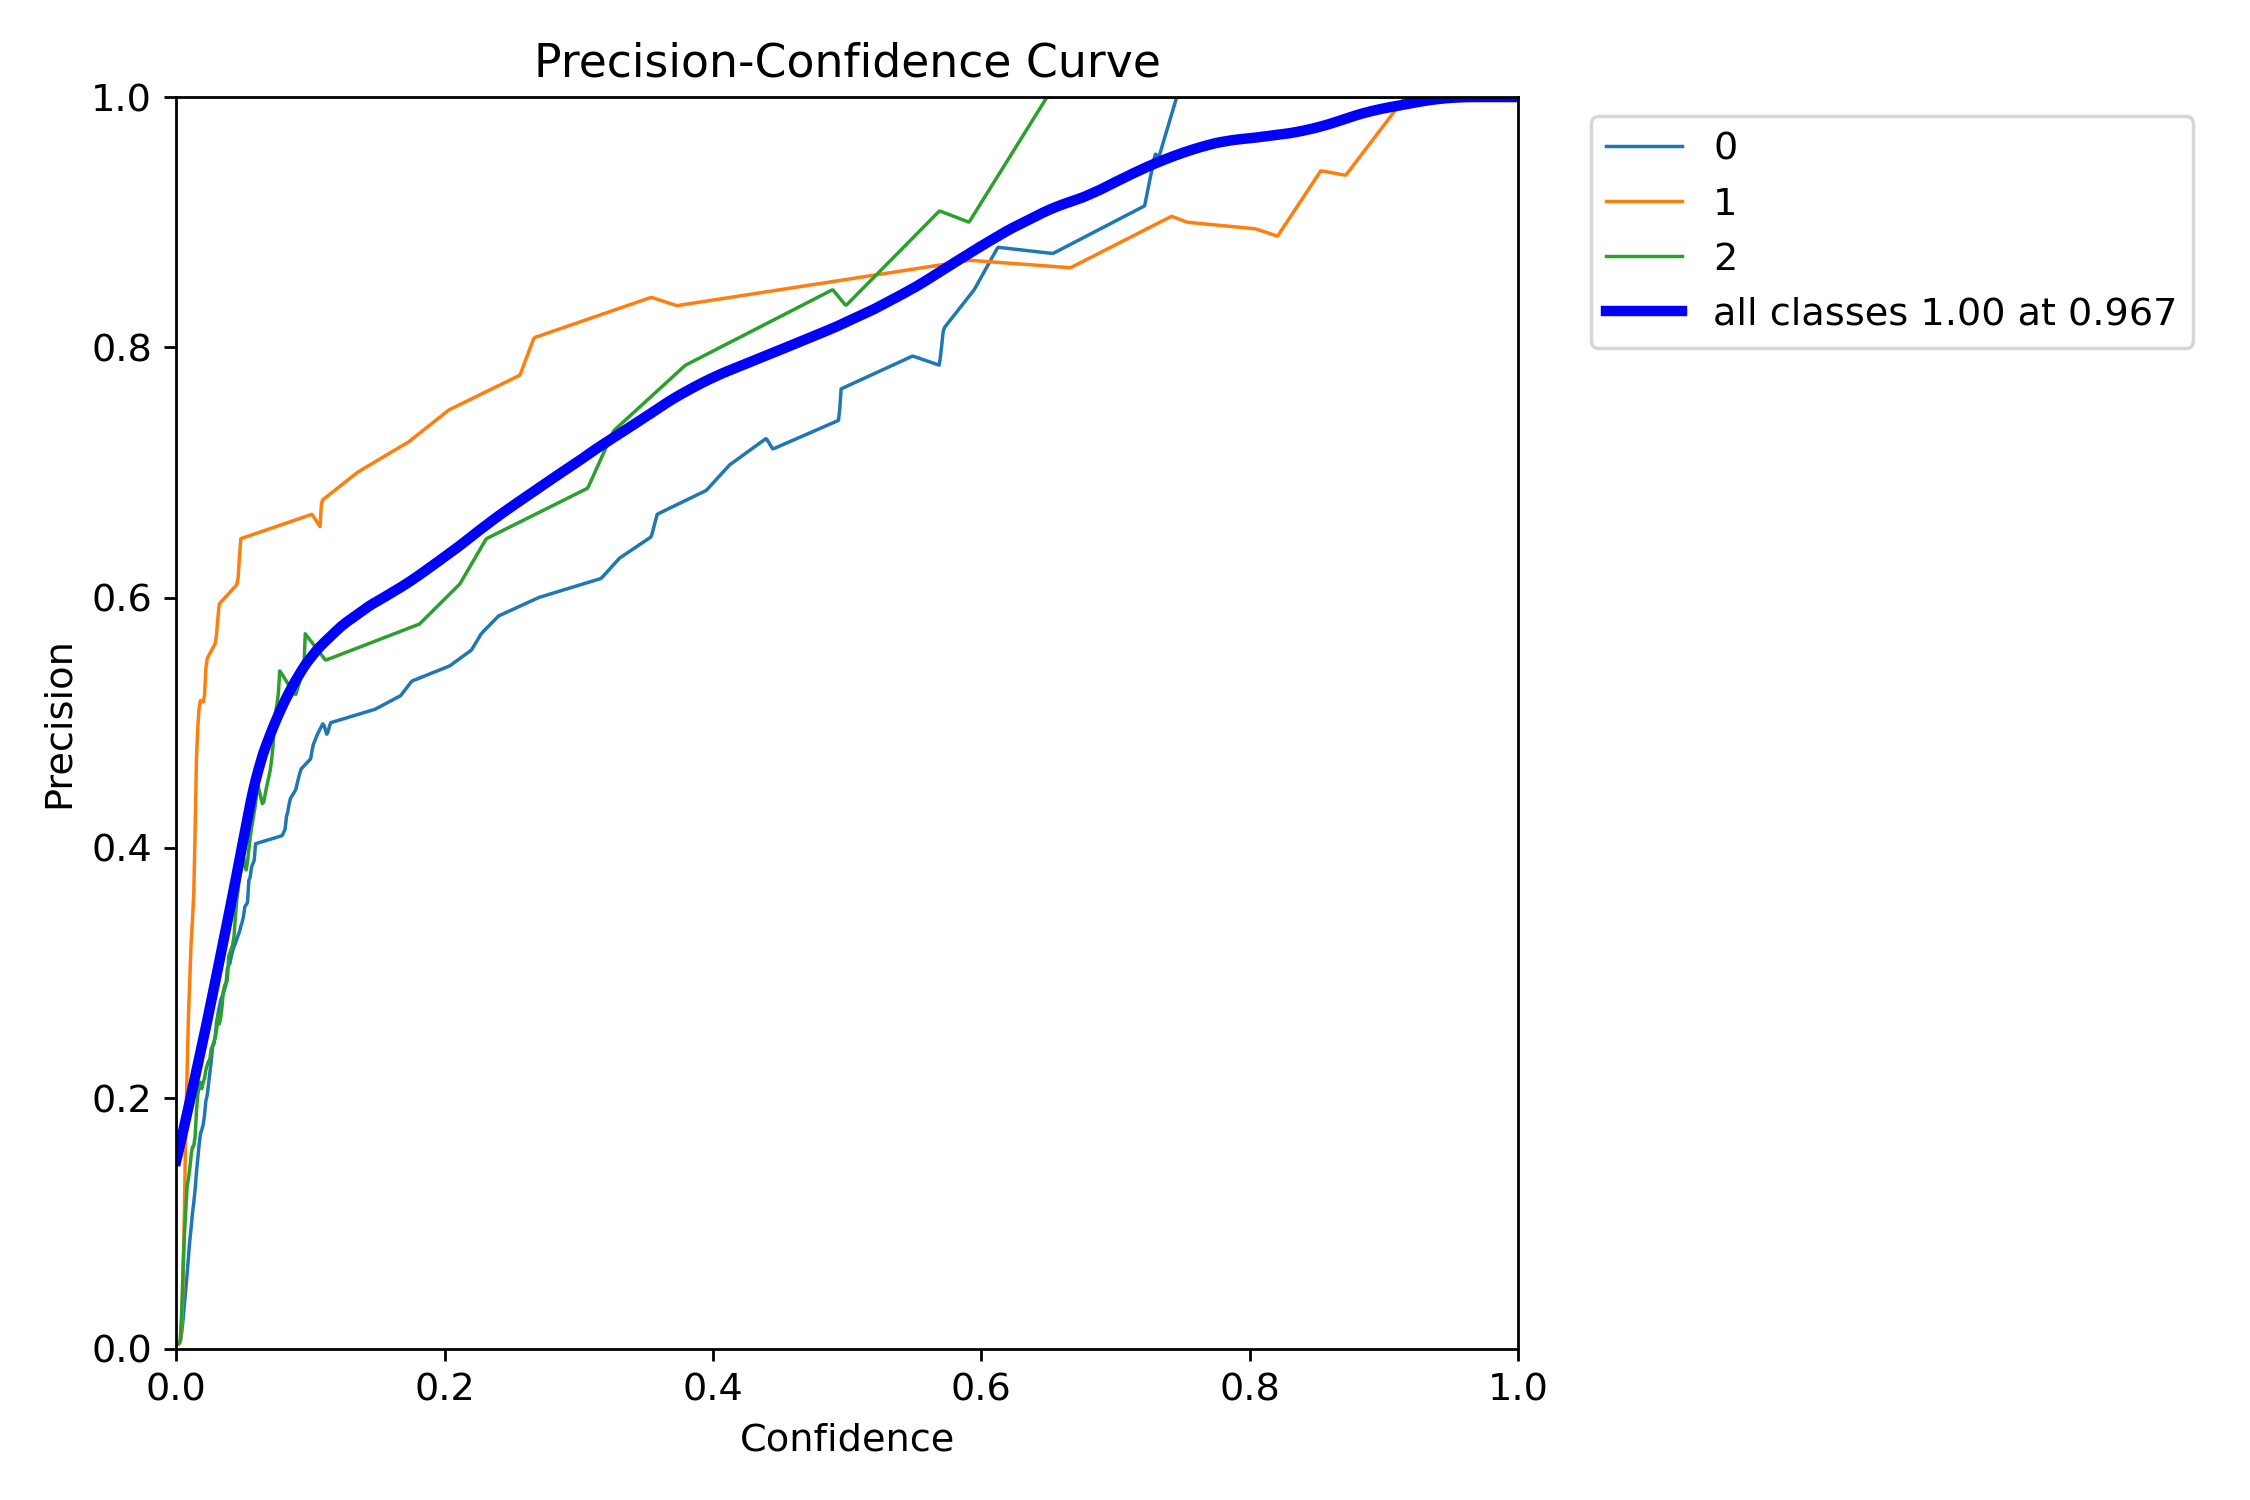

In [ ]:
Image("/content/runs/detect/train2/BoxP_curve.png",width=600)

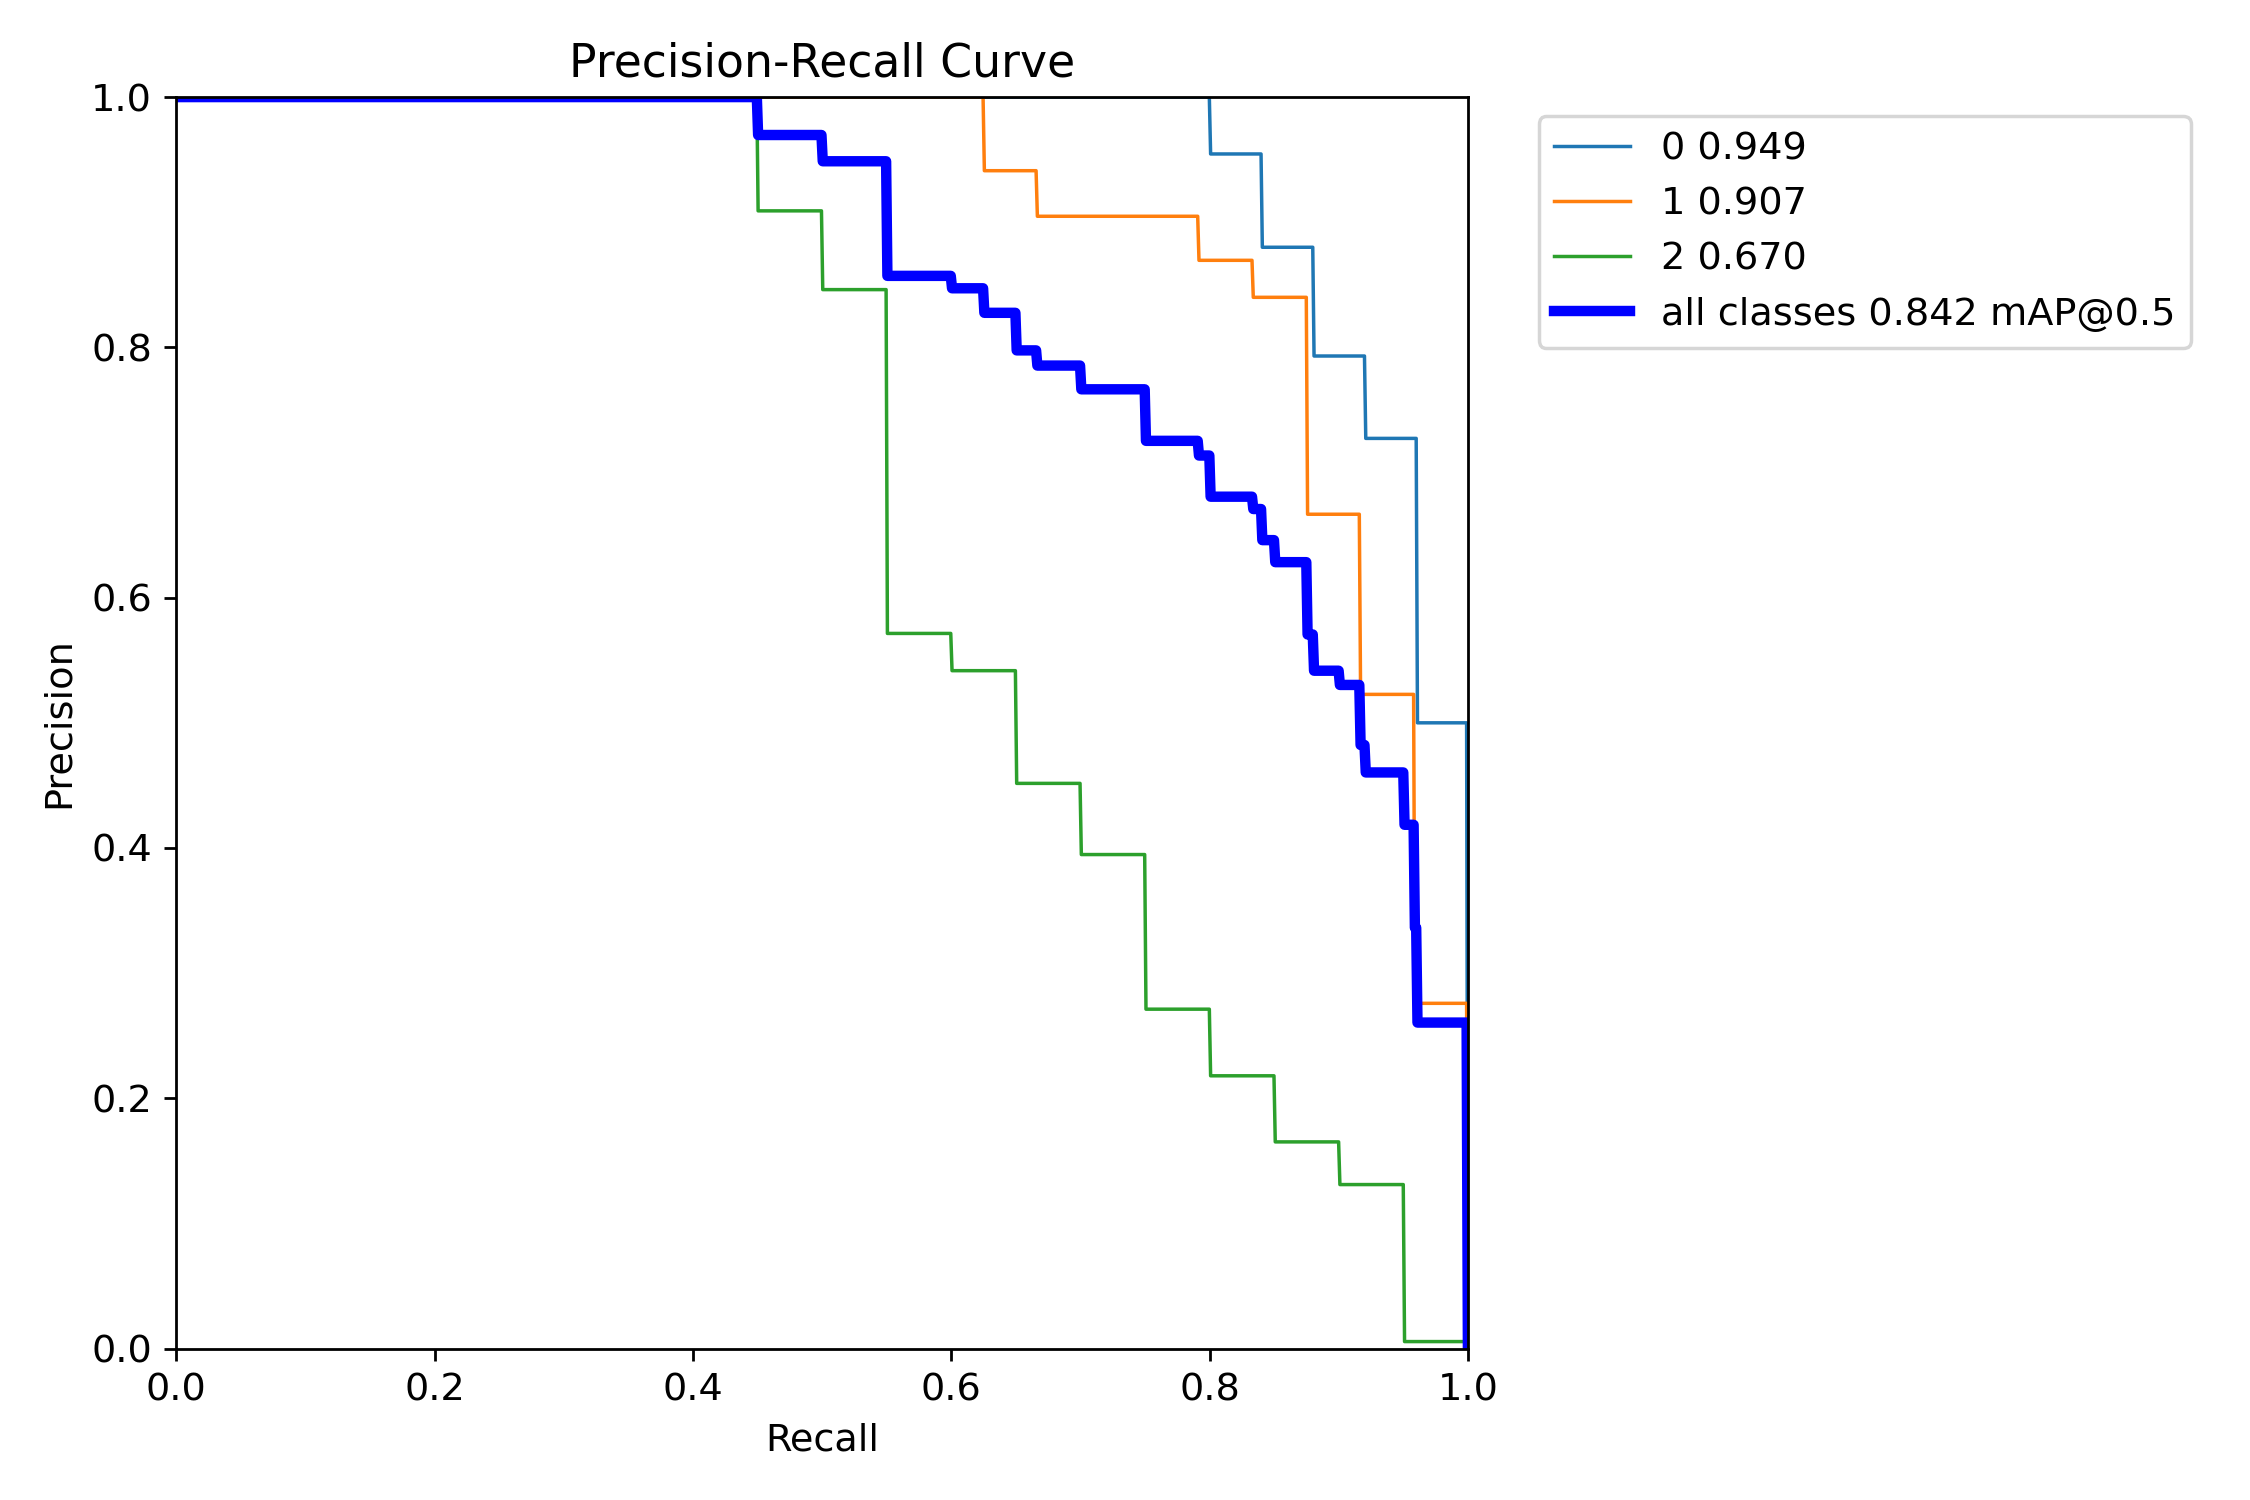

In [ ]:
Image("/content/runs/detect/train2/BoxPR_curve.png",width=600)

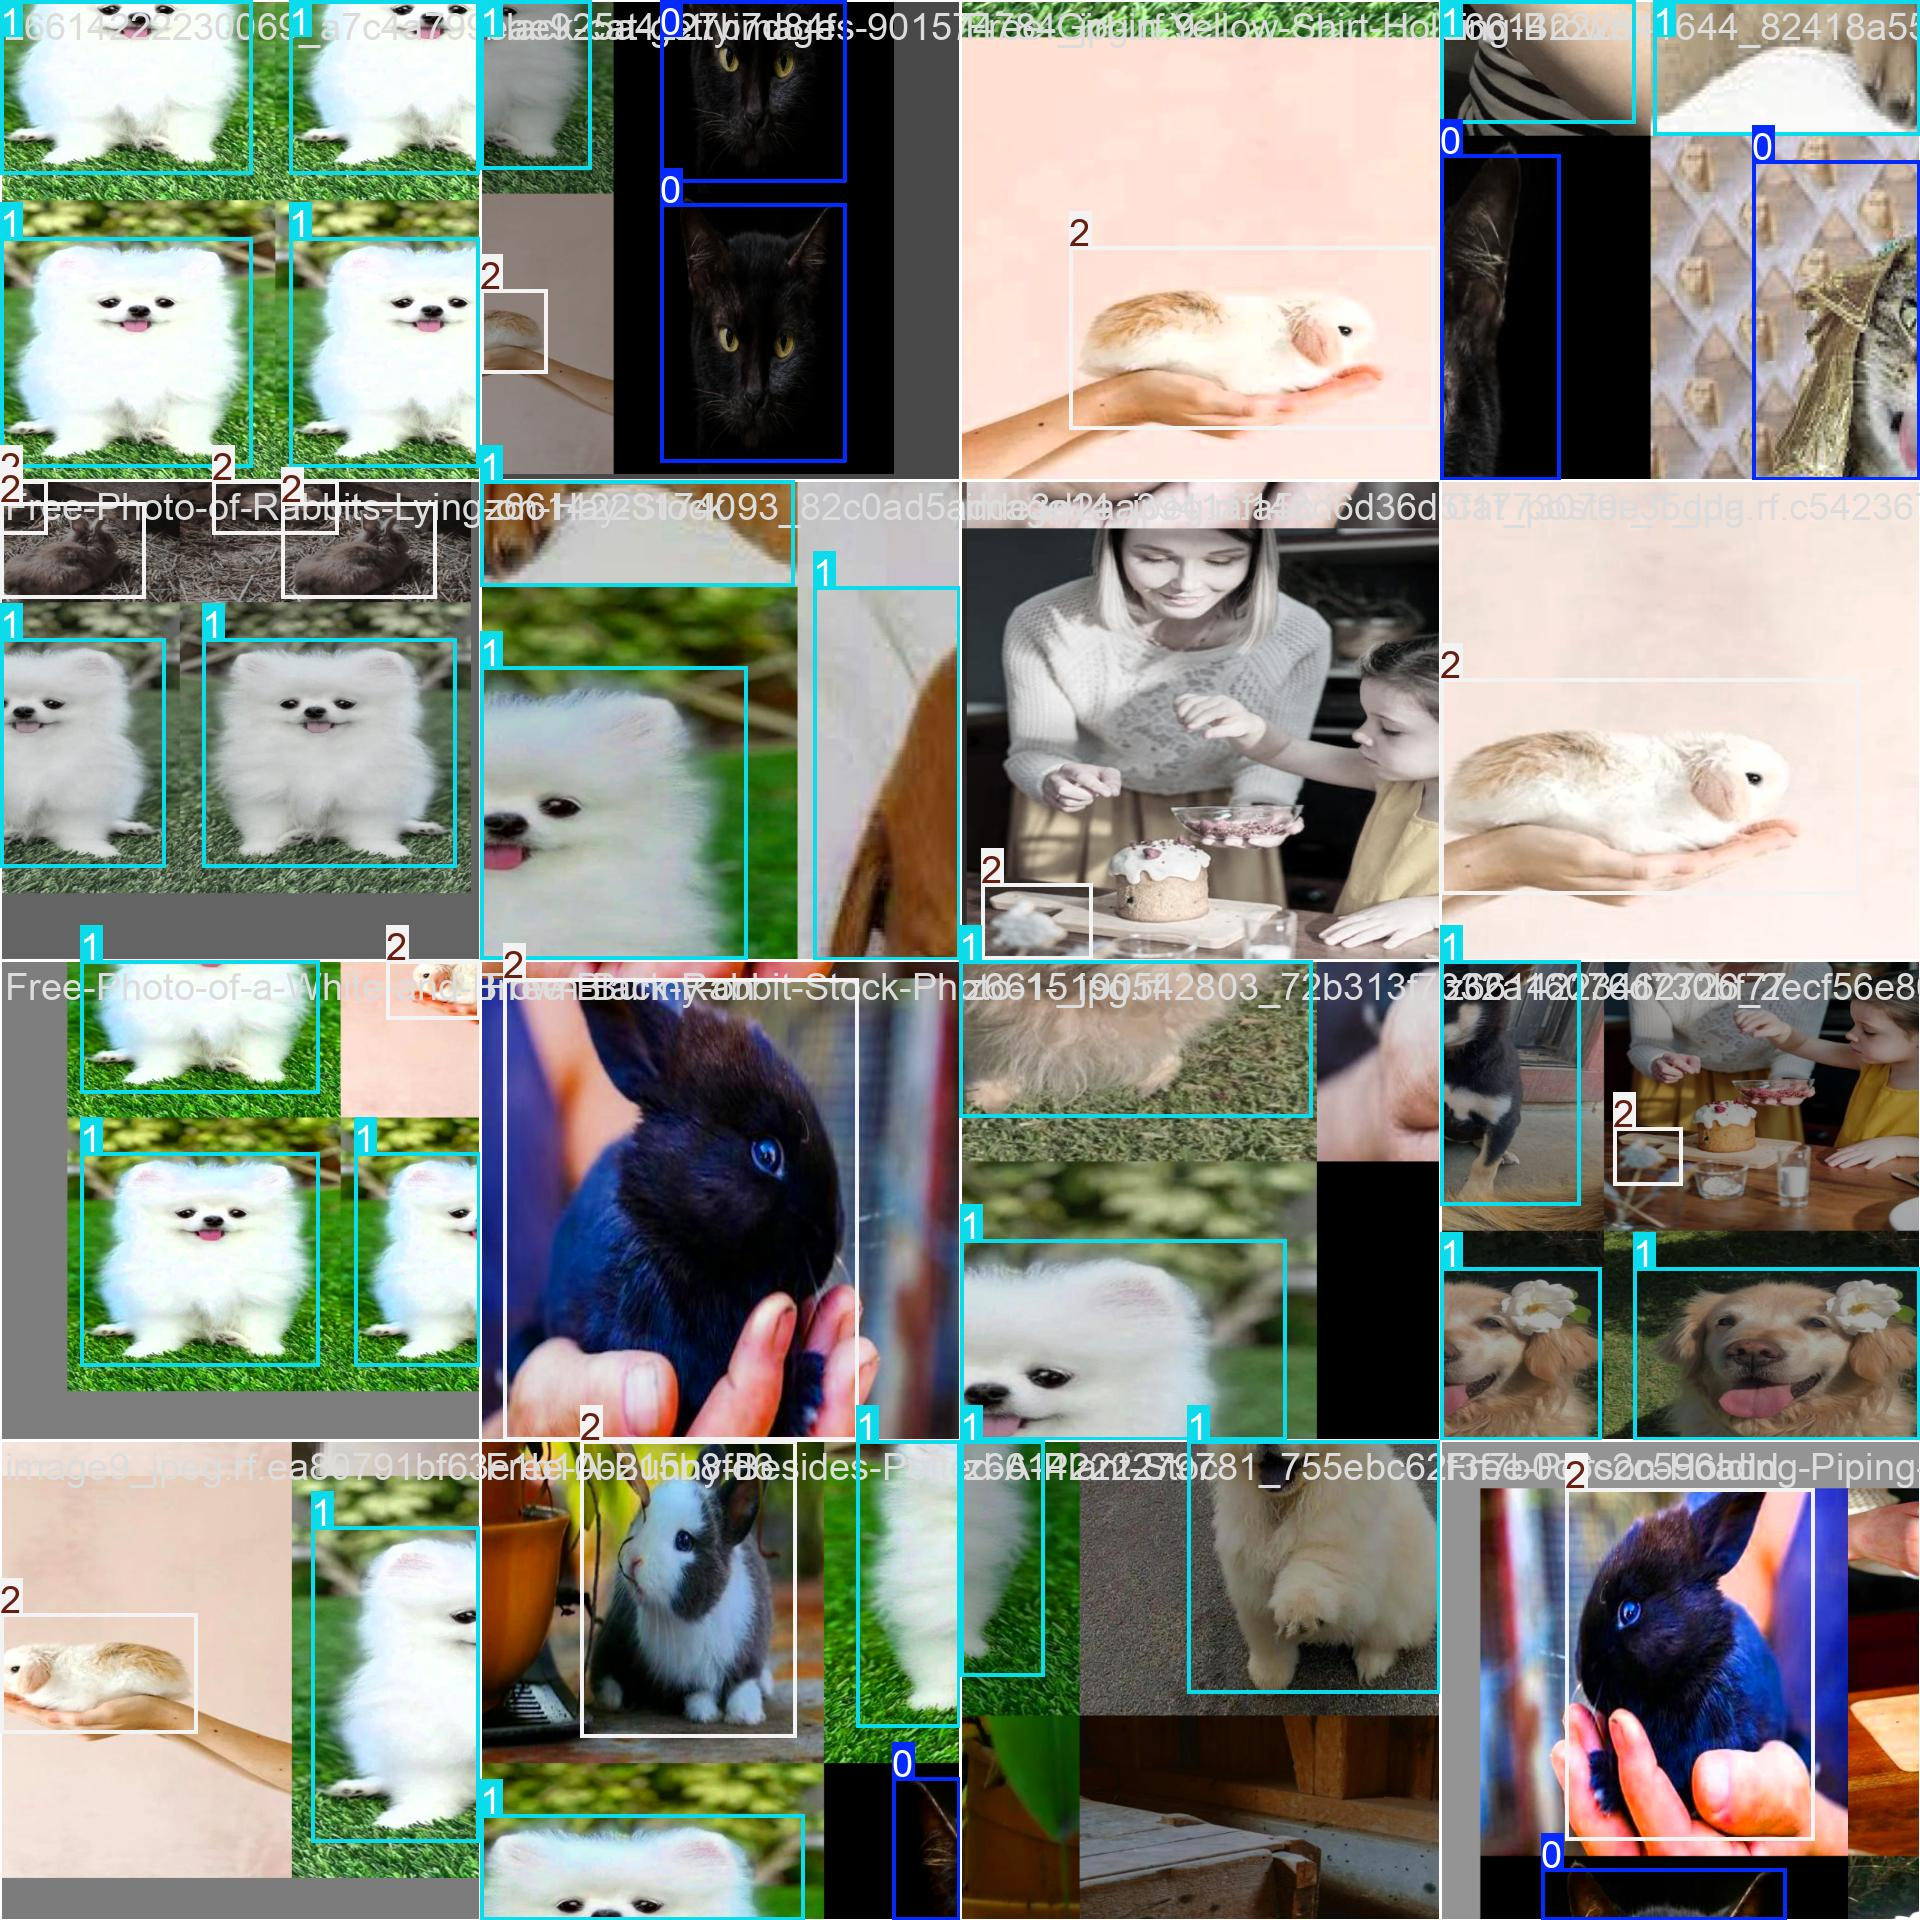

In [ ]:
Image("/content/runs/detect/train2/train_batch0.jpg",width=600)

In [ ]:
Image("/content/runs/detect/val/val_batch0_labels.jpg" ,width=600)

FileNotFoundError: No such file or directory: '/content/runs/detect/val/val_batch0_labels.jpg'

FileNotFoundError: No such file or directory: '/content/runs/detect/val/val_batch0_labels.jpg'

<IPython.core.display.Image object>

In [ ]:
from ultralytics import YOLO

# Load a model
  # load an official model
model = YOLO("/content/runs/detect/train2/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
metrics.box.map  # map50-95
metrics.box.map50  # map50
metrics.box.map75  # map75
metrics.box.maps  # a list containing mAP50-95 for each category

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1301.4±435.2 MB/s, size: 36.6 KB)
val: Scanning /content/animal-detection-task-2/valid/labels.cache... 60 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 60/60 77.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1it/s 1.9s
                   all         60         69      0.865      0.731      0.842      0.546
                     0         20         25      0.821       0.88      0.949      0.639
                     1         21         24      0.867      0.833      0.908      0.637
                     2         19         20      0.905       0.48      0.669      0.361
Speed: 5.5ms preprocess, 7.1ms inference, 0.0ms loss, 5.4ms postprocess per image
Results saved to /content/runs/detect/val


array([    0.63947,     0.63686,      0.3612])

In [ ]:
from ultralytics import YOLO

# Load a custom model
model = YOLO("/content/runs/detect/train2/weights/best.pt")

# Run inference on 'bus.jpg' with arguments
model.predict("/content/animal-detection-task-2/test/images", save=True, imgsz=640, conf=0.5)


image 1/30 /content/animal-detection-task-2/test/images/1800x1200_cat_relaxing_on_patio_other_jpg.rf.ae9d952e523454ea4d77cca8e5a233e7.jpg: 640x640 1 0, 10.3ms
image 2/30 /content/animal-detection-task-2/test/images/209147383_jpg.rf.809331d827b059acf179cf5727e47c28.jpg: 640x640 1 0, 8.9ms
image 3/30 /content/animal-detection-task-2/test/images/Free-A-Bunny-In-A-Basket-Stock-Photo-1-_jpg.rf.c55972d9693dd65a7f7577fafc35263c.jpg: 640x640 1 2, 7.9ms
image 4/30 /content/animal-detection-task-2/test/images/Free-Beige-Rabbit-Resting-on-Green-Grasses-during-Daytime-Stock-Photo-1-_jpg.rf.1146ff791c76d1f2a0926a8dd79af876.jpg: 640x640 1 0, 8.0ms
image 5/30 /content/animal-detection-task-2/test/images/Free-Chocolate-Cake-With-White-Icing-on-Brown-Wooden-Round-Tray-Stock-Photo_jpg.rf.7075d37b159ad85de56beacda6b031bd.jpg: 640x640 3 2s, 7.9ms
image 6/30 /content/animal-detection-task-2/test/images/Free-Close-Up-Photo-of-Rabbit-Stock-Photo-1-_jpg.rf.cd67799791f0e3a28ee8a45283cd98ef.jpg: 640x640 1 2, 7

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '0', 1: '1', 2: '2'}
 obb: None
 orig_img: array([[[ 81,  98, 124],
         [ 80,  97, 123],
         [ 79,  96, 122],
         ...,
         [ 32,  67,  63],
         [ 30,  65,  61],
         [ 30,  65,  61]],
 
        [[ 81,  98, 124],
         [ 81,  98, 124],
         [ 80,  97, 123],
         ...,
         [ 32,  67,  63],
         [ 30,  65,  61],
         [ 29,  64,  60]],
 
        [[ 81,  98, 124],
         [ 81,  98, 124],
         [ 81,  98, 124],
         ...,
         [ 31,  66,  62],
         [ 30,  65,  61],
         [ 29,  64,  60]],
 
        ...,
 
        [[217, 236, 249],
         [217, 236, 249],
         [218, 237, 250],
         ...,
         [177, 206, 227],
         [175, 206, 227],
         [174, 205, 226]],
 
        [[220, 238, 249],
         [220, 238, 249],
         [220, 238, 249],
         ...,
       